# Basic Image Processing with NumPy

**Q: Load an image and display it**
* Use cv2.imread() or PIL.Image.open() to load an image from the dataset.
* Display it using matplotlib.pyplot.imshow().
* Add a markdown cell explaining:
* How the image is stored in memory.
* The shape of the NumPy array.


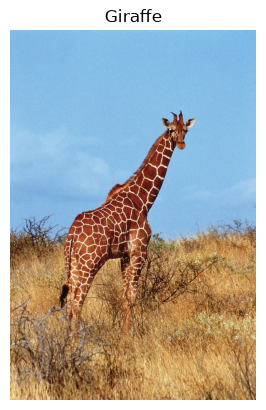

Image shape: (1600, 1067, 3)
Image dtype: uint8


In [8]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("D:/CitrusBits/pythonic-rebirth/images/giraffe_kenya.png")

# note -> OpenCV loads images in BGR order, not RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display it
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Giraffe")
plt.show()

print("Image shape:", img.shape)
print("Image dtype:", img.dtype)

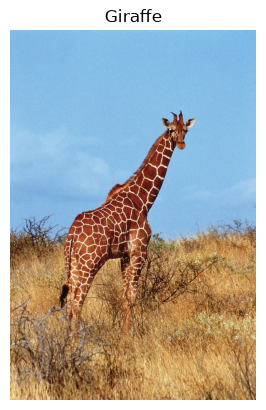

Image shape: (1600, 1067, 3)
Image dtype: uint8


In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = Image.open("D:/CitrusBits/pythonic-rebirth/images/giraffe_kenya.png")

# Convert to NumPy array
img_array = np.array(img)

# Display it
plt.imshow(img_array)
plt.axis('off')
plt.title("Giraffe")
plt.show()

print("Image shape:", img_array.shape)  # Image shape: (1600, 1067, 3) -> height, width, color
print("Image dtype:", img_array.dtype)

**How the image is stored in memory**
A digital image is stored as a NumPy array of pixel values

Each pixel holds a [R, G, B] value, with each channel ranging 0–255
(0 = no intensity, 255 = full intensity). E.g., (255, 0, 0) = red,
(0, 0, 0) = black, (255, 255, 255) = white.

Grayscale images have just one channel per pixel — a single 0–255
brightness value, no color info.

**Shape of the NumPy array**
`.shape` returns `(H, W, C)`:
- `H` = height in pixels (no. of rows)
- `W`= width in pixels (no. of cols)
- `C` = channels (3 for RGB, 4 with alpha, or omitted for grayscale)

E.g., `(400, 600, 3)` = 400px tall, 600px wide, 3 color channels.

**Q: Convert the image to a NumPy array**
* Convert the loaded image into a NumPy array using np.array().
* Print its shape, data type, and first few pixel values.
* Add a markdown cell explaining how pixel values are represented.


In [10]:
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("\nFirst 5x5 pixels (top-left corner):")
print(img_array[:5, :5])

# Single pixel value (top-left corner)
print("\nSingle pixel at (0,0):", img_array[0, 0])

# Just the Red channel values for the first 5x5 pixels
# print("\nRed channel only (first 5x5):")
# print(img_array[:5, :5, 0])

Shape: (1600, 1067, 3)
Data type: uint8

First 5x5 pixels (top-left corner):
[[[135 197 237]
  [137 199 240]
  [137 199 240]
  [135 197 237]
  [127 186 228]]

 [[129 191 231]
  [126 187 228]
  [126 187 228]
  [129 191 231]
  [132 191 233]]

 [[138 200 241]
  [127 188 229]
  [127 188 229]
  [138 200 241]
  [137 196 237]]

 [[131 193 234]
  [114 176 216]
  [114 176 216]
  [131 193 234]
  [141 200 242]]

 [[123 182 223]
  [126 185 227]
  [130 189 230]
  [134 193 235]
  [138 197 238]]]

Single pixel at (0,0): [135 197 237]


**How pixel values are represented**

Once converted to a NumPy array, the image becomes a grid of numbers.
Each individual pixel is represented by a small array of integers; one
value per color channel.


For example, a pixel value of `[255, 0, 0]` is pure red, `[0, 255, 0]` is
pure green, and `[128, 128, 128]` is mid-gray. Each of these three
numbers ranges from 0 to 255, since the array's data type is typically
`uint8` , an 8-bit unsigned integer, which can only represent values
from 0 to 255 (2^8 = 256 possible values).

The full image array combines all these pixel values into a 3D grid of
shape `(height, width, channels)`. So `img_array[0, 0]` gives you the
top-left pixel's [R, G, B] values, and `img_array[:5, :5]` gives you a
5x5 block of pixels, each with its own [R, G, B] triplet.

**Why `uint8` specifically?** It's memory-efficient and uses exactly one
byte (8 bits) per channel per pixel, which is enough precision for human
visual perception while keeping file sizes and memory usage low. This is
also why pixel values are always whole numbers, never decimals, in their
raw form.

**Q: Convert the NumPy array back to an image**
* Convert the NumPy array back to an image
* Display the re-generated image.
* Add a markdown cell explaining what happens during this conversion.


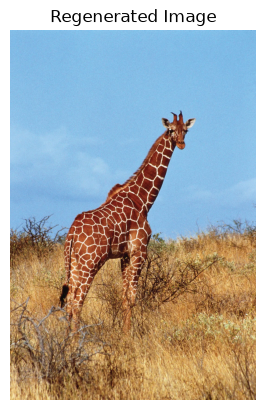

In [11]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# img_array is the NumPy array from the previous step

# Convert the numpy array back to an image
regenerated_img = Image.fromarray(img_array)

# displaying
plt.imshow(regenerated_img)
plt.axis('off')
plt.title("Regenerated Image")
plt.show()

# saving
regenerated_img.save("D:/CitrusBits/pythonic-rebirth/outputs/numpy_arr_to_image.jpg")

**Q:What happens during this conversion?**

`Image.fromarray()` takes a NumPy array and reconstructs it back into a
PIL Image object. It reads the array's shape (H, W, C) and reinterprets
each pixel's [R, G, B] values as actual color data, rebuilding the image
pixel by pixel exactly as it was represented in the array.

This conversion is lossless as long as the array's dtype stays `uint8`
throughout since no information was discarded when we converted the
image to an array in the first place, converting it back reconstructs
the exact same image with no visible difference from the original.

If the array had been modified in dtype (e.g., converted to float for
some computation, like normalization) or in value (e.g., some processing
step changed pixel intensities), the regenerated image would reflect
those changes, and it wouldn't match the original exactly. This is the
basis for most image processing operations: convert to an array,
manipulate the numbers, then convert back to visualize the result.

**Q: Create color-filtered images**
> From the original image array, create:
* Grayscale image
* Red scale image (keep red channel, set green & blue to 0).
* Green scale image (keep green channel, set red & blue to 0).
* Blue scale image (keep blue channel, set red & green to 0).
> Add a markdown cell explaining:
* How each color channel works.
* Why zeroing out other channels isolates the desired color.


red_img[:, :, 1]`:

* First : select all rows (every value along the height dimension)
* Second : select all columns (every value along the width dimension)
* 1 select only index 1 along the channel dimension

Also,
Since channels are ordered [R, G, B] → index 0 = Red, index 1 = Green, index 2 = Blue. So index 1 specifically targets the Green channel.

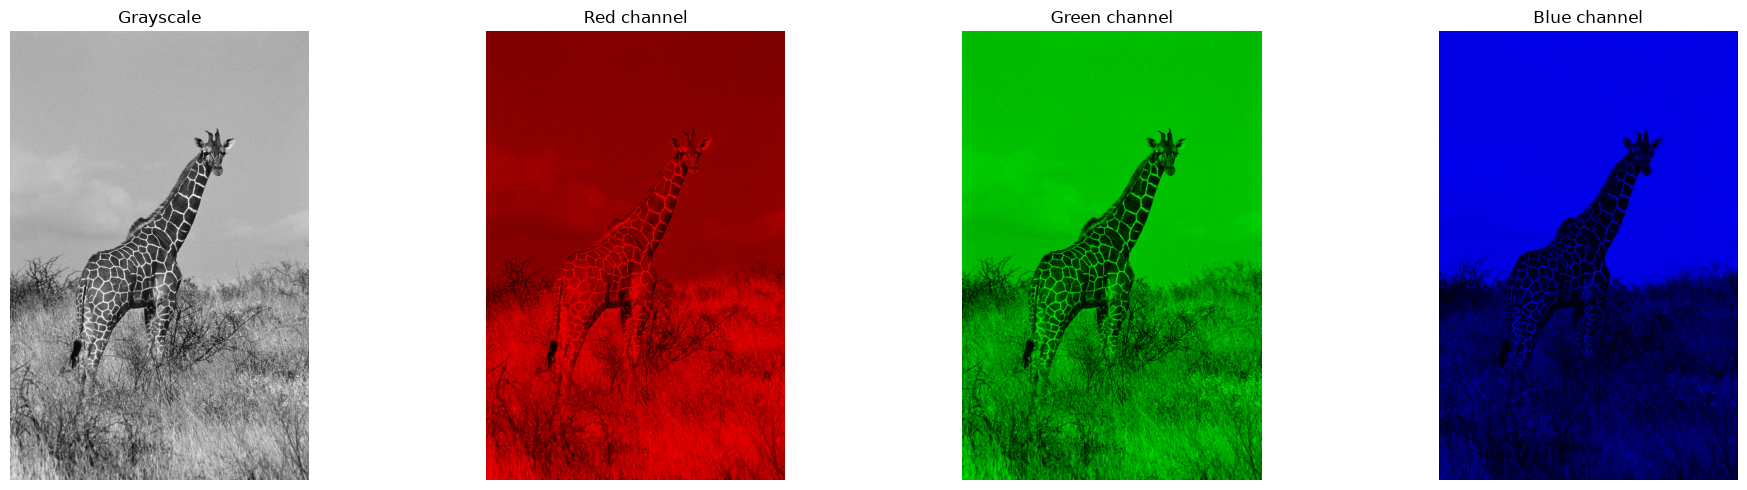

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# img_array is your original RGB NumPy array, shape (H, W, 3)

# --- Grayscale ---
# Using luminosity method (weighted average — matches human eye sensitivity)
gray_img = np.dot(img_array[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

# red channel only
red_img = img_array.copy()
# red img is formed by zeroing out green and blue
red_img[:, :, 1] = 0  # zero out green
red_img[:, :, 2] = 0  # zero out blue

# green channel only
green_img = img_array.copy()
green_img[:, :, 0] = 0  # zero out red
green_img[:, :, 2] = 0  # zero out blue

# blue channel only
blue_img = img_array.copy()
blue_img[:, :, 0] = 0  # zero out red
blue_img[:, :, 1] = 0  # zero out green

# --- Display all four ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale")
axes[0].axis('off')

axes[1].imshow(red_img)
axes[1].set_title("Red channel")
axes[1].axis('off')

axes[2].imshow(green_img)
axes[2].set_title("Green channel")
axes[2].axis('off')

axes[3].imshow(blue_img)
axes[3].set_title("Blue channel")
axes[3].axis('off')

plt.tight_layout()
plt.savefig('D:/CitrusBits/pythonic-rebirth/outputs/color_filtered_images.png')
plt.show()